In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder


In [3]:
df= pd.read_csv(r"C:\Users\PRATHEEK POOJARY\OneDrive\Desktop\Machine Learning\datasets\salaries.csv")
df

,company,job,degree,salary_more_then_100k
0,google,sales executive,bachelors,0
1,google,sales executive,masters,0
2,google,business manager,bachelors,1
3,google,business manager,masters,1
4,google,computer programmer,bachelors,0
5,google,computer programmer,masters,1
6,abc pharma,sales executive,masters,0
7,abc pharma,computer programmer,bachelors,0
8,abc pharma,business manager,bachelors,0
9,abc pharma,business manager,masters,1


In [4]:
encoder=LabelEncoder()
df['company_e']=encoder.fit_transform(df['company'])
df['job_e']=encoder.fit_transform(df['job'])
df['degree_e']=encoder.fit_transform(df['degree'])
df=df.drop(['company','job','degree'],axis=1)
df

,salary_more_then_100k,company_e,job_e,degree_e
0,0,2,2,0
1,0,2,2,1
2,1,2,0,0
3,1,2,0,1
4,0,2,1,0
5,1,2,1,1
6,0,0,2,1
7,0,0,1,0
8,0,0,0,0
9,1,0,0,1


In [5]:
x=df.drop(['salary_more_then_100k'],axis=1)
y=df['salary_more_then_100k']

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,classification_report,accuracy_score

In [7]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.30)

In [8]:
model= RandomForestClassifier(n_estimators=100,max_depth=5)
model.fit(x_train,y_train)
model.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 5,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [9]:
y_pred= model.predict(x_test)

In [10]:
accuracy_score(y_test,y_pred)

0.4

In [11]:
print('\n ',classification_report(y_test,y_pred))


                precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.50      0.67      0.57         3

    accuracy                           0.40         5
   macro avg       0.25      0.33      0.29         5
weighted avg       0.30      0.40      0.34         5



<Axes: >

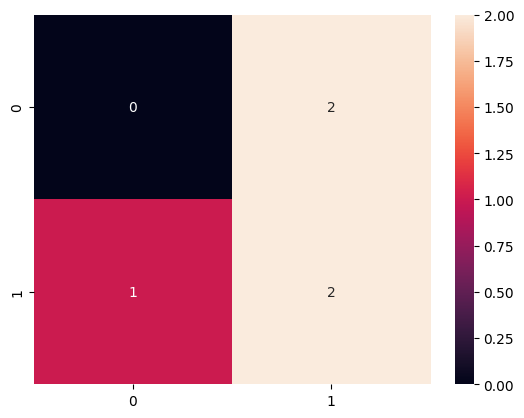

In [12]:
cm=confusion_matrix(y_test,y_pred)
import seaborn as sns
sns.heatmap(data=cm, annot=True)

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 10],
}

grid = GridSearchCV(RandomForestClassifier(), param_grid)
grid.fit(x_train, y_train)
print(grid.best_params_)
print(grid.best_score_)

c:\Users\PRATHEEK POOJARY\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_split.py:737: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


{'max_depth': 3, 'n_estimators': 100}
0.5


for TITANIC dataset